# AutoML acotado — selección honesta de variables

La pregunta: **¿darle más variables al modelo y dejar que las use baja el MAE, o solo sobreajusta?**

Reglas del juego (lo que separa un AutoML útil de uno que se engaña):
1. **Todo se mide fuera de muestra** con leave-one-contest-out. Nada se decide por el ajuste en train.
2. **Métrica única:** MAE de la cuota de voto (puntos porcentuales), siempre al lado del baseline de
   proporcionalidad (cuota de interacciones = cuota de voto).
3. **La regularización hace la poda**, no yo: con multicolinealidad fuerte, dejamos que ElasticNet
   mande a cero lo redundante.
4. **Honestidad sobre el sobreajuste de selección:** si pruebas muchas configuraciones y te quedas
   con la mejor, ese "mejor" ya está sesgado. Por eso la selección automática va **anidada** (CV
   interno para elegir, CV externo para medir).

> Sin abstención: no se observa antes de la urna, no sirve para *nowcasting*. Fuera del núcleo.


---
## 0 — Datos y pool de features


In [1]:
import os, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut

sns.set_theme(style="whitegrid"); pd.set_option("display.max_columns", None)
%matplotlib inline
AZUL_SABANA, ROJO, GRIS = "#1A2F6F", "#FF4B4B", "#A9A9A9"


In [2]:
# ---- Carga ----
base_path = os.getcwd()
excel_path = os.path.join(os.path.dirname(base_path), "Colombia", "Resultados electorales.xlsx")
df_redes      = pd.read_csv(os.path.join(base_path,"resultados","redes_unificadas.csv"), sep=";", encoding="utf-8-sig")
df_electoral  = pd.read_excel(excel_path, sheet_name="Candidatos E-26 ALC").rename(columns={"ID Candidato":"id_candidato"})
df_poblacion  = pd.read_excel(excel_path, sheet_name="Población 2023 (DANE)")
df_seguidores = pd.read_csv(os.path.join(base_path,"resultados","seguidores.csv"), sep=";", encoding="utf-8-sig").fillna(0)
for ex in ["68547","68081"]:
    df_redes = df_redes[~df_redes["id_candidato"].str.contains(ex, na=False)]
df_completo = df_redes.merge(df_seguidores[["id_candidato","tiktok_followers","twitter_followers","facebook_followers"]], on="id_candidato", how="left")
df_completo = df_completo.merge(df_electoral[["id_candidato","Candidato","Ganador","Votos"]], on="id_candidato", how="left")
df_completo["DIVIPOLA"] = df_completo["id_candidato"].astype(str).str.split("-").str[1].str.zfill(5)
df_poblacion["DIVIPOLA"] = pd.to_numeric(df_poblacion["DIVIPOLA"], errors="coerce").fillna(0).astype(int).astype(str).str.zfill(5)
df_completo = df_completo.merge(df_poblacion[["DIVIPOLA","Población 2023"]], on="DIVIPOLA", how="left")
print(f"Candidatos: {df_completo['id_candidato'].nunique()} | Municipios: {df_completo['DIVIPOLA'].nunique()}")


Candidatos: 120 | Municipios: 31


In [3]:
FOLLOWER_COL = {"Facebook":"facebook_followers","Twitter":"twitter_followers","TikTok":"tiktok_followers"}
def prepare_lens_data(df, metric_col, lente="dominancia", platform=None):
    data = df.copy()
    if platform is not None: data = data[data["red_social"]==platform]
    if len(data)==0 or metric_col not in data.columns: return pd.DataFrame()
    seg = data[FOLLOWER_COL[platform]] if platform else data[list(FOLLOWER_COL.values())].sum(axis=1)
    data = data.assign(_seg=seg)
    agg = data.groupby(["DIVIPOLA","id_candidato","Candidato","Ganador"]).agg(
        metric_sum=(metric_col,"sum"), n_posts=(metric_col,"count"),
        votos=("Votos","first"), pob=("Población 2023","first")).reset_index()
    if lente in ("totales","dominancia"): agg["v"]=agg["metric_sum"]
    elif lente=="por_post":               agg["v"]=agg["metric_sum"]/agg["n_posts"].replace(0,np.nan)
    agg = agg.replace([np.inf,-np.inf], np.nan)
    agg["pct_metric"] = (agg["v"]/agg.groupby("DIVIPOLA")["v"].transform("sum"))*100
    return agg[agg.groupby("DIVIPOLA")["v"].transform("sum")>0]

def to_logit(p_pct, eps=1e-3):
    p = np.clip(p_pct/100, eps, 1-eps); return np.log(p/(1-p))

# Pool de features: 6 cuotas digitales (logit) + 2 de territorio + 1 moderador
combos = [("likes","dominancia","f_likes_dom"),("comentarios","dominancia","f_coment_dom"),
          ("compartidos","dominancia","f_compart_dom"),("likes","por_post","f_likes_pp"),
          ("comentarios","por_post","f_coment_pp"),("compartidos","por_post","f_compart_pp")]
b = prepare_lens_data(df_completo,"likes","dominancia",None)
b["total_votos"] = b.groupby("DIVIPOLA")["votos"].transform("sum")
b["vote_frac"]   = (b["votos"]/b["total_votos"]).clip(1e-4,1-1e-4)
b["n_candidatos"]= b.groupby("DIVIPOLA")["id_candidato"].transform("count")
b["log_pob"]     = np.log(b["pob"].clip(lower=1))
base = b[["id_candidato","DIVIPOLA","Candidato","Ganador","vote_frac","n_candidatos","log_pob"]].copy()
for tipo,lente,nombre in combos:
    d = prepare_lens_data(df_completo,tipo,lente,None)[["id_candidato","pct_metric"]]
    base = base.merge(d.rename(columns={"pct_metric":nombre}), on="id_candidato", how="left")
for nombre in [c[2] for c in combos]:
    base[nombre] = to_logit(base[nombre])
base["mod_likes_pob"] = base["f_likes_dom"] * (base["log_pob"] - base["log_pob"].mean())
base = base.dropna(subset=[c[2] for c in combos]+["vote_frac","log_pob"]).reset_index(drop=True)

DIGITAL = [c[2] for c in combos]
TERR    = ["n_candidatos","log_pob"]
POOL    = DIGITAL + TERR + ["mod_likes_pob"]
print(f"Filas: {len(base)} | Contiendas: {base['DIVIPOLA'].nunique()} | Pool: {len(POOL)} features")
print(POOL)


Filas: 120 | Contiendas: 31 | Pool: 9 features
['f_likes_dom', 'f_coment_dom', 'f_compart_dom', 'f_likes_pp', 'f_coment_pp', 'f_compart_pp', 'n_candidatos', 'log_pob', 'mod_likes_pob']


---
## 1 — Multicolinealidad: ¿la hay? (sí, y por eso importa la regularización)

Antes de darle variables al modelo, miremos cuánto se pisan entre sí. VIF > 5 ya es preocupante;
> 10 es severo. Esto justifica usar ElasticNet (que tolera y poda colinealidad) en vez de meter
todo a una regresión normal.


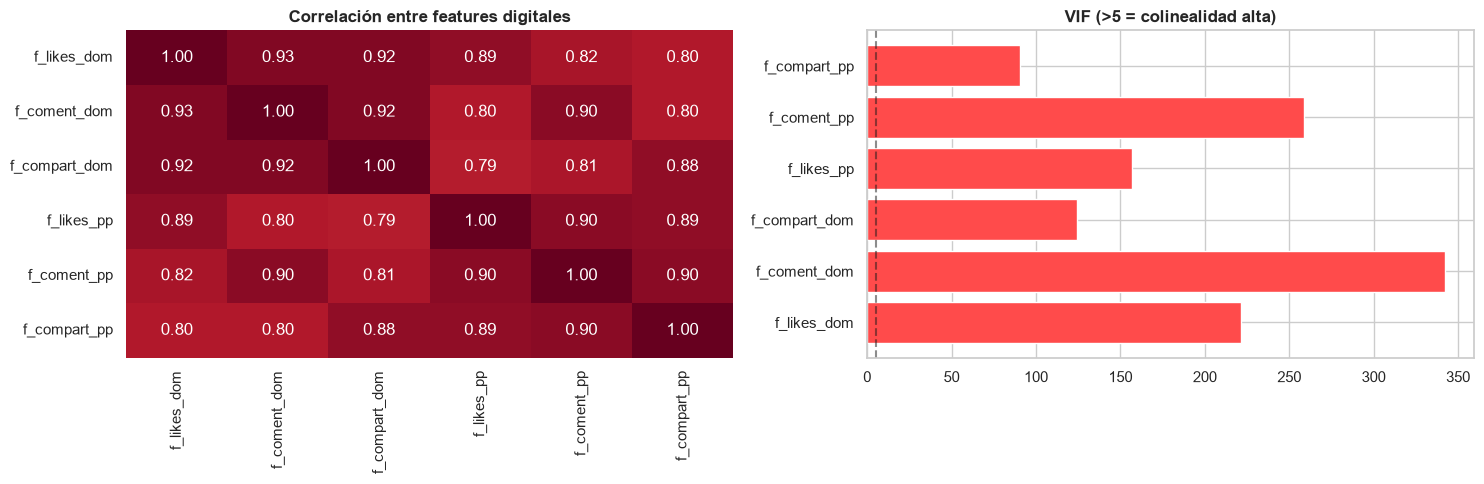

,feature,VIF
0,f_likes_dom,221.5
1,f_coment_dom,342.3
2,f_compart_dom,124.4
3,f_likes_pp,156.8
4,f_coment_pp,258.5
5,f_compart_pp,90.7


In [4]:
Xv = sm.add_constant(base[DIGITAL])
vif = pd.DataFrame({"feature": DIGITAL,
                    "VIF": [round(variance_inflation_factor(Xv.values, i+1),1) for i in range(len(DIGITAL))]})
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(base[DIGITAL].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0], cbar=False)
axes[0].set_title("Correlación entre features digitales", fontweight="bold")
axes[1].barh(vif["feature"], vif["VIF"], color=[ROJO if v>5 else AZUL_SABANA for v in vif["VIF"]])
axes[1].axvline(5, color="k", ls="--", alpha=0.5); axes[1].set_title("VIF (>5 = colinealidad alta)", fontweight="bold")
plt.tight_layout(); plt.show()
vif


---
## 2 — El motor de evaluación (leave-one-contest-out)


In [5]:
logo = LeaveOneGroupOut()

def logo_glm(base, feats):
    '''Logit fraccional: predicción OOS de la cuota por candidato.'''
    X = base[feats].values.astype(float); y = base["vote_frac"].values; g = base["DIVIPOLA"].values
    pred = np.full(len(y), np.nan)
    for tr, te in logo.split(X, y, g):
        sc = StandardScaler().fit(X[tr])
        Xtr = sm.add_constant(sc.transform(X[tr])); Xte = sm.add_constant(sc.transform(X[te]), has_constant="add")
        try: pred[te] = sm.GLM(y[tr], Xtr, family=sm.families.Binomial()).fit().predict(Xte)
        except Exception: pred[te] = y[tr].mean()
    return pred

def metricas(base, pred):
    y = base["vote_frac"].values
    mae = np.mean(np.abs(y - pred))*100
    r2  = 1 - np.sum((y-pred)**2)/np.sum((y-y.mean())**2)
    tmp = base.assign(pred=pred); ac=tot=0
    for _, s in tmp.groupby("DIVIPOLA"):
        ac += int(s["vote_frac"].idxmax()==s["pred"].idxmax()); tot+=1
    return dict(MAE_pp=round(mae,2), R2_oos=round(r2,3), top1=round(100*ac/tot,1))

# Baseline de proporcionalidad (la referencia a vencer)
bl = metricas(base, (base["f_likes_dom"].apply(lambda z: 1/(1+np.exp(-z)))).values)
print("Baseline proporcionalidad (cuota interacciones = cuota voto):", bl)


Baseline proporcionalidad (cuota interacciones = cuota voto): {'MAE_pp': np.float64(12.61), 'R2_oos': np.float64(0.185), 'top1': 71.0}


---
## 3 — Escalera de especificaciones (la frontera)

Subimos de "solo likes" a "todo + territorio", cada una con logit fraccional y MAE fuera de muestra.
Reportamos **todas** (no solo la ganadora) para ver dónde agregar variables deja de ayudar.


In [6]:
specs = {
    "Solo likes_dom":               ["f_likes_dom"],
    "Dominancia (3)":               ["f_likes_dom","f_coment_dom","f_compart_dom"],
    "Por_post (3)":                 ["f_likes_pp","f_coment_pp","f_compart_pp"],
    "Dominancia + por_post (6)":    DIGITAL,
    "likes + territorio":           ["f_likes_dom","n_candidatos","log_pob"],
    "Dominancia + territorio":      ["f_likes_dom","f_coment_dom","f_compart_dom","n_candidatos","log_pob"],
    "TODO digital + territorio (8)":DIGITAL+TERR,
    "likes + moderador(pob)":       ["f_likes_dom","mod_likes_pob"],
}
filas = [{"especificación":"BASELINE proporcionalidad","k":0, **bl}]
for nombre, fs in specs.items():
    filas.append({"especificación":nombre, "k":len(fs), **metricas(base, logo_glm(base, fs))})
escalera = pd.DataFrame(filas).sort_values("MAE_pp").reset_index(drop=True)
escalera


,especificación,k,MAE_pp,R2_oos,top1
0,likes + moderador(pob),2,10.33,0.509,71.0
1,likes + territorio,3,10.34,0.510,71.0
2,Dominancia + territorio,5,10.67,0.475,64.5
3,TODO digital + territorio (8),8,10.70,0.458,54.8
4,Solo likes_dom,1,11.52,0.460,71.0
5,Dominancia + por_post (6),6,11.63,0.428,61.3
6,Dominancia (3),3,11.78,0.426,67.7
7,Por_post (3),3,11.94,0.413,58.1
8,BASELINE proporcionalidad,0,12.61,0.185,71.0


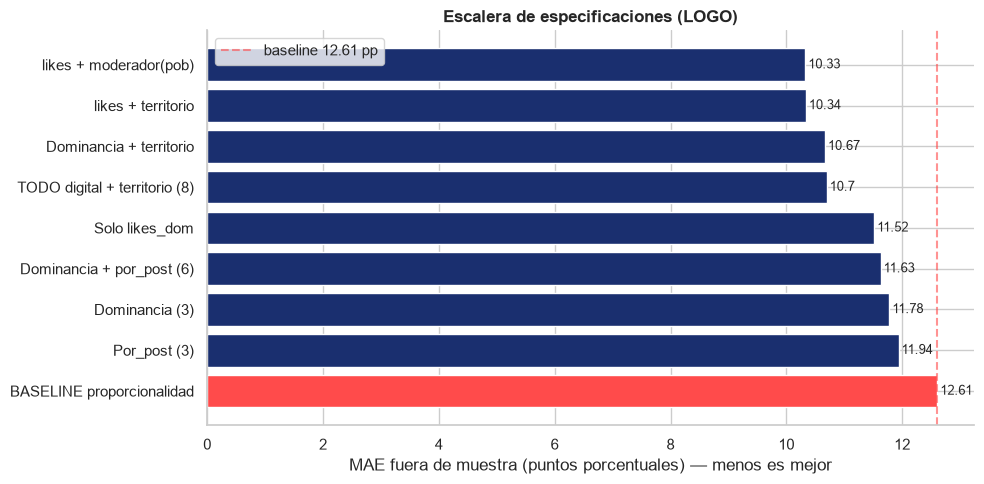

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
e = escalera.sort_values("MAE_pp", ascending=False)
ax.barh(e["especificación"], e["MAE_pp"],
        color=[ROJO if "BASELINE" in s else AZUL_SABANA for s in e["especificación"]])
ax.axvline(bl["MAE_pp"], color=ROJO, ls="--", alpha=0.6, label=f"baseline {bl['MAE_pp']} pp")
for yi,v in enumerate(e["MAE_pp"]): ax.text(v+0.05, yi, f"{v}", va="center", fontsize=9)
ax.set_xlabel("MAE fuera de muestra (puntos porcentuales) — menos es mejor")
ax.set_title("Escalera de especificaciones (LOGO)", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()


---
## 4 — Selección automática con ElasticNet (anidada y honesta)

Le damos **todo el pool** y dejamos que la regularización decida qué sobrevive. Para no engañarnos,
la fuerza de regularización se elige con CV **interno** (sobre las contiendas de entrenamiento) y el
desempeño se mide con CV **externo**. Trabaja sobre logit(cuota) y devolvemos a escala de cuota.


In [9]:
def enet_oos(base, feats, l1_grid=(0.3,0.5,0.8,1.0)):
    X = base[feats].values.astype(float); vf = base["vote_frac"].values
    yl = np.log(vf/(1-vf)); g = base["DIVIPOLA"].values
    pred = np.full(len(vf), np.nan); coefs_folds = []
    for tr, te in logo.split(X, yl, g):
        inner = list(LeaveOneGroupOut().split(X[tr], yl[tr], g[tr]))
        sc = StandardScaler().fit(X[tr])
        m = ElasticNetCV(l1_ratio=list(l1_grid), cv=inner, alphas=np.logspace(-3, 1, 30), max_iter=20000).fit(sc.transform(X[tr]), yl[tr])
        pred[te] = 1/(1+np.exp(-m.predict(sc.transform(X[te]))))
        coefs_folds.append(m.coef_)
    return pred, np.array(coefs_folds)

pred_enet, coefs = enet_oos(base, POOL)
print("ElasticNet sobre TODO el pool (selección anidada):", metricas(base, pred_enet))

# ¿Qué features sobrevivieron, y con qué consistencia entre folds?
estabilidad = pd.DataFrame({
    "feature": POOL,
    "%_folds_no_cero": [round(100*np.mean(np.abs(coefs[:,j])>1e-8),0) for j in range(len(POOL))],
    "coef_medio": [round(coefs[:,j].mean(),3) for j in range(len(POOL))],
}).sort_values("%_folds_no_cero", ascending=False)
print("\nEstabilidad de selección (qué tan seguido cada feature sobrevive a la poda):")
estabilidad


ElasticNet sobre TODO el pool (selección anidada): {'MAE_pp': np.float64(9.57), 'R2_oos': np.float64(0.518), 'top1': 64.5}

Estabilidad de selección (qué tan seguido cada feature sobrevive a la poda):


,feature,%_folds_no_cero,coef_medio
0,f_likes_dom,100.0,0.374
3,f_likes_pp,100.0,0.133
8,mod_likes_pob,100.0,0.558
7,log_pob,100.0,0.205
6,n_candidatos,100.0,-0.398
1,f_coment_dom,94.0,0.102
5,f_compart_pp,87.0,0.041
2,f_compart_dom,74.0,0.079
4,f_coment_pp,13.0,0.004


---
## 5 — ¿Ayuda la no-linealidad? (un árbol regularizado, como control)

Probamos *gradient boosting* superficial. Si no le gana a la regresión, es la confirmación de que
con 31 contiendas la no-linealidad solo añade varianza.


In [10]:
def logo_gbm(base, feats):
    X = base[feats].values.astype(float); vf = base["vote_frac"].values
    yl = np.log(vf/(1-vf)); g = base["DIVIPOLA"].values; pred = np.full(len(vf), np.nan)
    for tr, te in logo.split(X, yl, g):
        m = HistGradientBoostingRegressor(max_depth=2, max_iter=120, learning_rate=0.05,
                                          min_samples_leaf=15, l2_regularization=1.0, random_state=0)
        m.fit(X[tr], yl[tr]); pred[te] = 1/(1+np.exp(-m.predict(X[te])))
    return pred

print("Gradient Boosting (superficial) sobre el pool:", metricas(base, logo_gbm(base, POOL)))


Gradient Boosting (superficial) sobre el pool: {'MAE_pp': np.float64(9.91), 'R2_oos': np.float64(0.515), 'top1': 67.7}


---
## 6 — Veredicto

Junta todo y léelo así:

- **Si la mejor especificación curada y ElasticNet quedan parejas y por debajo del baseline de
  proporcionalidad** → tienes un modelo que aporta sobre la ingenuidad, y agregar más allá de un
  puñado de features no ayuda. *Ese es el hallazgo limpio y defendible.*
- **Las features que ElasticNet mantiene en >70% de los folds** son tu set final robusto. Las que
  poda casi siempre, sácalas: el dato dijo que no aportan.
- **Si el GBM no le gana a la regresión**, cierras la puerta a la no-linealidad con evidencia, no por opinión.
- **Cuidado con el sobreajuste de selección:** el MAE de la *mejor* fila de la escalera está
  ligeramente optimista (probaste varias). El número honesto para reportar es el de **ElasticNet
  anidado**, que ya pagó ese costo.

> Siguiente y último paso real: congelar el set que sobrevive, reentrenar en todas las alcaldías
> 2023, y correr el **núcleo** el día antes de la **presidencial 2026**. Esa es la validación que
> ningún CV puede igualar.


# Conclusiones — Modelo de nowcasting electoral basado en interacciones en redes

## 1. El recorrido

El modelado avanzó en tres etapas, cada una corrigiendo el límite de la anterior:

1. **Modelo binario (¿quién gana?).** Útil como baseline, pero pobre en información: cada contienda
   aporta un solo bit y solo ~9 de 31 son casos "informativos" (donde el líder digital no ganó).
   Ningún modelo superó de forma estable el baseline ingenuo.
2. **Modelo continuo (¿qué cuota de voto?).** El objetivo correcto de la tesis: predecir la cuota de
   voto de cada candidato. Usa los 120 candidatos como objetivos reales con gradiente.
3. **Selección honesta de variables (AutoML acotado).** Regularización elastic-net con selección
   anidada para decidir, sin sobreajuste, qué variables aportan.

## 2. Hallazgos empíricos

| Modelo | MAE (pp) | R² fuera de muestra | Top-1 |
|---|---|---|---|
| Baseline proporcionalidad (cuota interacc. = cuota voto) | 12.61 | 0.185 | 71% |
| Núcleo digital (solo dominancia de likes) | 11.52 | 0.460 | 71% |
| **Modelo completo (ElasticNet, selección anidada)** | **9.57** | **0.518** | 64.5% |
| Gradient boosting (no-linealidad) | 9.91 | 0.515 | 67.7% |

Lectura: el modelo final predice la cuota de voto con **error medio de 9.57 puntos porcentuales**,
una mejora de ~3 pp sobre la proporcionalidad ingenua. La cifra es honesta (la selección de
variables se midió de forma anidada, pagando el costo del sobreajuste de selección).

## 3. Decisiones metodológicas y su justificación

- **Validación leave-one-contest-out.** Las features son cuotas que comparten denominador dentro de
  cada municipio; partir candidatos de una misma contienda entre entrenamiento y prueba sería fuga de
  información. Se deja cada contienda **entera** afuera, lo que simula la situación real de predecir
  una elección nueva.
- **Regularización por multicolinealidad severa.** Los VIF de las features digitales superan 100
  (likes, comentarios y compartidos se mueven casi en bloque). Una regresión sin penalización daría
  coeficientes inestables; elastic-net tolera la colinealidad y poda lo redundante.
- **Selección anidada.** Probar muchas configuraciones y quedarse con la mejor infla el resultado;
  el anidamiento (CV interno para elegir, CV externo para medir) evita ese sesgo.
- **Métrica.** MAE en puntos porcentuales (interpretable) y R² fuera de muestra, siempre frente al
  baseline de proporcionalidad. El top-1 se conserva solo como puente con el análisis binario.

## 4. Los dos modelos

- **Núcleo agnóstico** — solo señales digitales (dominancia de likes, likes por publicación) más el
  número de candidatos. Es transferible a cualquier elección y es el que se valida en la
  presidencial 2026.
- **Capa Colombia** — añade variables del territorio (población y su moderador). Baja el MAE a 9.57,
  pero es específica del nivel municipal colombiano: no se transfiere a una elección nacional.

## 5. Hallazgo sustantivo: la población **modera** el efecto de las redes

El coeficiente más fuerte del modelo final no es una variable digital ni el territorio por separado,
sino la **interacción población × dominancia de likes**. Interpretación: en municipios grandes,
dominar las redes se traduce con más fuerza en votos que en municipios pequeños. La población no
actúa como efecto directo (es constante dentro de la contienda y se diluye), sino como **moderador**
de cuánto pesan las interacciones.

## 6. Tensión entre gradiente y cima

El modelo final mejora la predicción de la cuota (gradiente) pero su top-1 baja a 64.5%, por debajo
del 71% del baseline. No es contradicción: predecir bien la cuota de *todos* los candidatos y acertar
*quién es el #1* son objetivos distintos. El modelo optimizado para cuota cede algo de exactitud en
la clasificación del ganador. Es coherente y reportable.

## 7. Limitaciones

- **Tamaño de muestra.** 31 contiendas es el cuello de botella. Los resultados deben reportarse con su
  intervalo de confianza; diferencias de uno o dos municipios están dentro del ruido.
- **Techo del dato.** Existen excepciones irreducibles (p. ej. Bogotá, donde un candidato dominó las
  redes sin ganar). Ningún modelo basado solo en interacciones las puede capturar.
- **No-linealidad.** El gradient boosting no superó a la regresión regularizada: con estos datos, la
  flexibilidad adicional solo añade varianza.

## 8. Variables candidatas a futuro (económicas, criminalidad)

Cualquier variable de nivel municipal (desempleo, índice de riesgo, criminalidad) es **constante
dentro de la contienda**, igual que la población. Por tanto:

- Como **efecto principal** sobre la cuota, se diluye (no diferencia candidatos del mismo municipio).
- Su papel legítimo es como **moderador** (interacción con una señal digital): ¿el efecto de las
  redes es más fuerte o más débil en municipios de alto riesgo / alto desempleo?
- **Criterio de admisión:** una variable nueva entra solo si **sobrevive a la poda de ElasticNet en
  >70% de los folds** y **baja el MAE anidado**. Si no, es una narrativa, no un predictor.
- Pocas y con teoría detrás: añadir muchas reintroduce multicolinealidad y sobreajuste.

## 9. Validación definitiva

La prueba que ningún CV iguala: entrenar el **núcleo agnóstico** con las alcaldías 2023 y correrlo el
día antes de la **presidencial 2026**, sobre datos que no existían al entrenar. Esa es la validación
prospectiva real de un modelo de nowcasting.

Dicho en una frase para Caballero: "El modelo tiene dos versiones: un núcleo agnóstico (solo señales digitales + número de candidatos) que se valida prospectivamente en la presidencial 2026, y una capa colombiana (con moderadores de territorio) que mejora la predicción a nivel municipal pero no es transferible a una elección nacional."